In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("ggplot")

In [3]:
project_root = Path.cwd().parent

processed = r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed"

In [5]:
performance = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\performance_metrics.csv")
cagr = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\cagr_report.csv")
sharpe = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\sharpe_ratio.csv")
sortino = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\sortino_ratio.csv")
alpha_beta = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\alpha_beta.csv")
drawdown = pd.read_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\max_drawdown.csv")

print("Files loaded successfully.")

Files loaded successfully.


In [7]:
print(cagr.head())
print(sharpe.head())
print(sortino.head())
print(alpha_beta.head())
print(drawdown.head())

   amfi_code   CAGR (%)
0     100016   2.637074
1     100025   4.458210
2     100033  30.123153
3     101206  23.538361
4     101207   7.938765
   amfi_code  Sharpe Ratio
0     100016     -0.201517
1     100025     -0.567095
2     100033      1.093699
3     101206      1.027213
4     101207      0.162661
   amfi_code  Sortino Ratio
0     100016      -0.348196
1     100025      -0.915371
2     100033       1.823824
3     101206       1.785592
4     101207       0.274615
   amfi_code     Alpha      Beta
0     100016  0.043439  0.039109
1     100025  0.045444 -0.008652
2     100033  0.255114  0.005311
3     101206  0.203109  0.027073
4     101207  0.069089  0.071078
   amfi_code  Max Drawdown (%)
0     100016        -24.734441
1     100025         -4.308264
2     100033        -16.217209
3     101206        -11.291596
4     101207        -35.446916


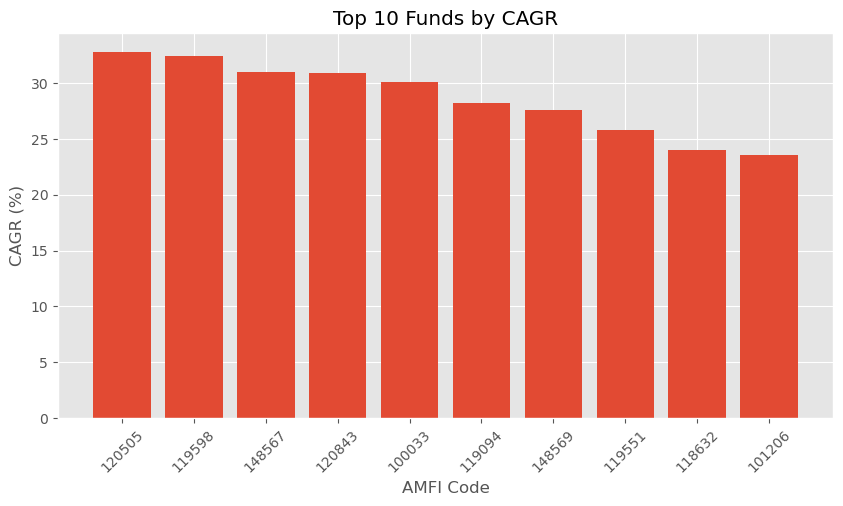

In [9]:
top_cagr = cagr.sort_values("CAGR (%)", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_cagr["amfi_code"].astype(str), top_cagr["CAGR (%)"])
plt.title("Top 10 Funds by CAGR")
plt.xlabel("AMFI Code")
plt.ylabel("CAGR (%)")
plt.xticks(rotation=45)
plt.show()

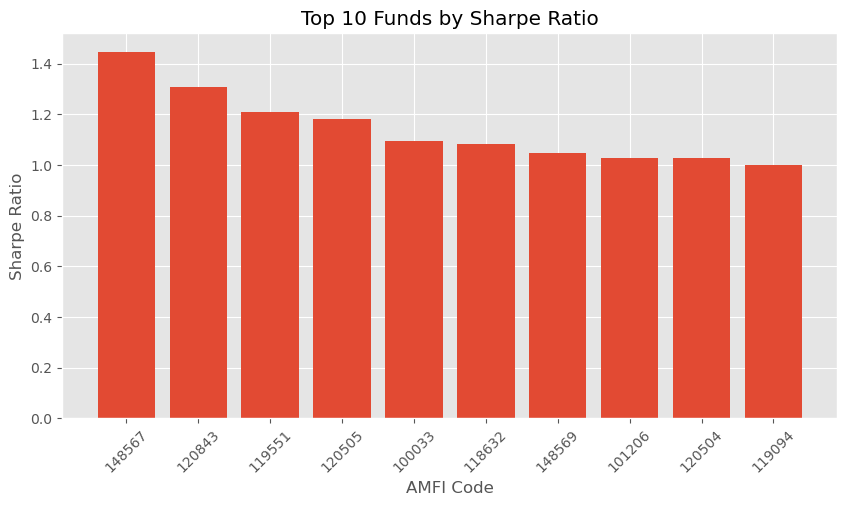

In [11]:
top_sharpe = sharpe.sort_values("Sharpe Ratio", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_sharpe["amfi_code"].astype(str), top_sharpe["Sharpe Ratio"])
plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sharpe Ratio")
plt.xticks(rotation=45)
plt.show()

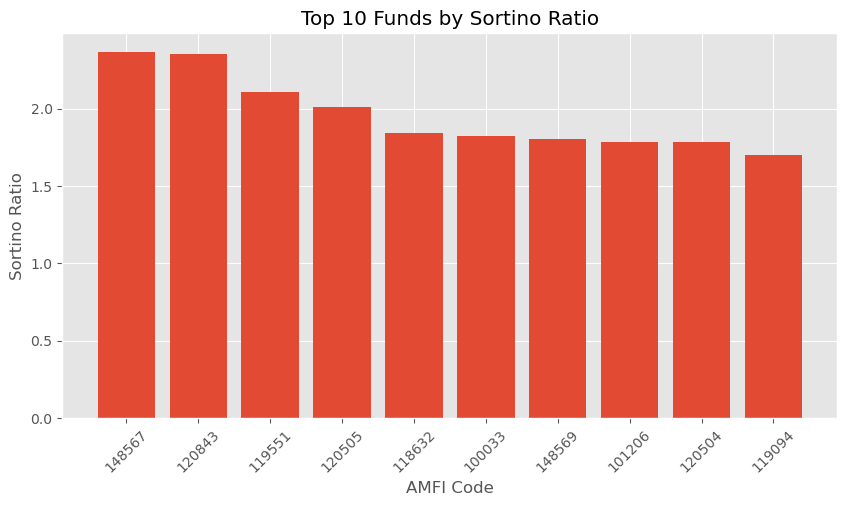

In [13]:
top_sortino = sortino.sort_values("Sortino Ratio", ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_sortino["amfi_code"].astype(str), top_sortino["Sortino Ratio"])
plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("AMFI Code")
plt.ylabel("Sortino Ratio")
plt.xticks(rotation=45)
plt.show()

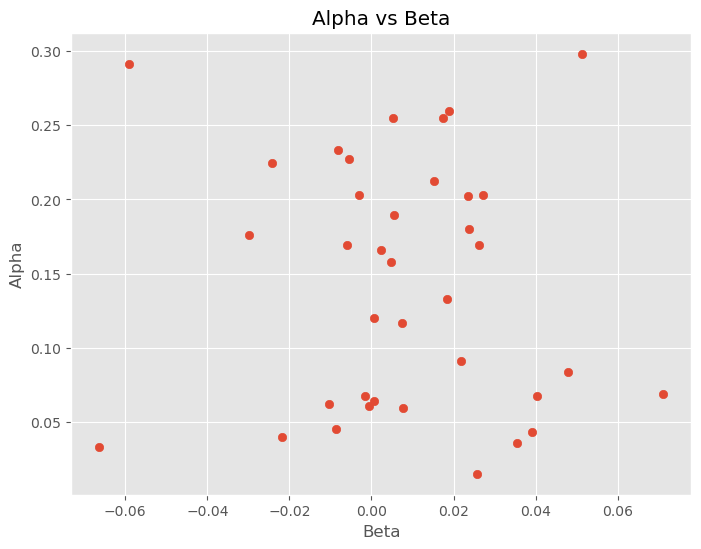

In [15]:
plt.figure(figsize=(8,6))

plt.scatter(
    alpha_beta["Beta"],
    alpha_beta["Alpha"],
)

plt.xlabel("Beta")
plt.ylabel("Alpha")
plt.title("Alpha vs Beta")

plt.grid(True)

plt.show()

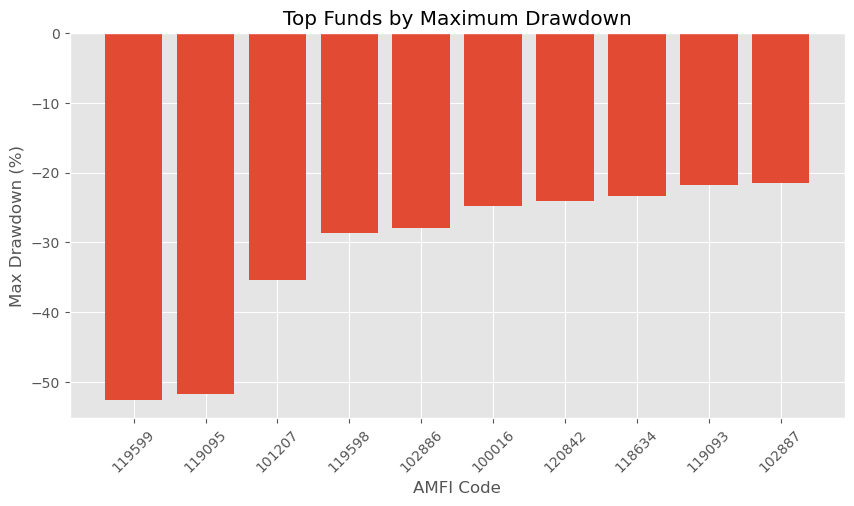

In [17]:
worst_drawdown = drawdown.sort_values("Max Drawdown (%)").head(10)

plt.figure(figsize=(10,5))

plt.bar(
    worst_drawdown["amfi_code"].astype(str),
    worst_drawdown["Max Drawdown (%)"]
)

plt.title("Top Funds by Maximum Drawdown")

plt.xlabel("AMFI Code")

plt.ylabel("Max Drawdown (%)")

plt.xticks(rotation=45)

plt.show()

In [19]:
summary = cagr.merge(sharpe,on="amfi_code")

summary = summary.merge(sortino,on="amfi_code")

summary = summary.merge(alpha_beta,on="amfi_code")

summary = summary.merge(drawdown,on="amfi_code")

summary.head()

,amfi_code,CAGR (%),Sharpe Ratio,Sortino Ratio,Alpha,Beta,Max Drawdown (%)
0,100016,2.637074,-0.201517,-0.348196,0.043439,0.039109,-24.734441
1,100025,4.458210,-0.567095,-0.915371,0.045444,-0.008652,-4.308264
2,100033,30.123153,1.093699,1.823824,0.255114,0.005311,-16.217209
3,101206,23.538361,1.027213,1.785592,0.203109,0.027073,-11.291596
4,101207,7.938765,0.162661,0.274615,0.069089,0.071078,-35.446916


In [21]:
summary.sort_values(
    "Sharpe Ratio",
    ascending=False
).head(10)

,amfi_code,CAGR (%),Sharpe Ratio,Sortino Ratio,Alpha,Beta,Max Drawdown (%)
34,148567,30.974108,1.448291,2.368342,0.259250,0.018790,-11.265729
30,120843,30.907455,1.306744,2.352942,0.224506,-0.024161,-12.973968
19,119551,25.804686,1.208267,2.103952,0.202612,0.023470,-15.012385
25,120505,32.827406,1.180101,2.010035,0.298101,0.051352,-18.188514
2,100033,30.123153,1.093699,1.823824,0.255114,0.005311,-16.217209
9,118632,24.049493,1.081659,1.839859,0.212215,0.015295,-17.414075
36,148569,27.595888,1.046727,1.802776,0.255039,0.017396,-16.396743
3,101206,23.538361,1.027213,1.785592,0.203109,0.027073,-11.291596
24,120504,23.295119,1.026524,1.785043,0.202956,-0.003047,-12.588276
16,119094,28.214417,0.998231,1.698390,0.233242,-0.008082,-20.960884


In [27]:
summary.to_csv(r"C:\Users\chand\Downloads\mutual_fund_analytics\data\processed\advanced_analytics_summary.csv",
    index=False
)

print("Summary saved successfully.")

Summary saved successfully.
